In [117]:
# Import packages expected to be used
import numpy as np
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split as tts
from sklearn.metrics import mean_squared_error as myMSE
from sklearn.linear_model import LinearRegression
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm
import os

In [118]:
# Load the dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/abalone/abalone.data"
column_names = ['Sex', 'Length', 'Diameter', 'Height', 'Whole weight', 
                'Shucked weight', 'Viscera weight', 'Shell weight', 'Rings']

# Read data, specifying header=None
df = pd.read_csv(url, header=None, names=column_names)

# Show imported dataset
df.head(12) # Displays df

,Sex,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7
5,I,0.425,0.300,0.095,0.3515,0.1410,0.0775,0.120,8
6,F,0.530,0.415,0.150,0.7775,0.2370,0.1415,0.330,20
7,F,0.545,0.425,0.125,0.7680,0.2940,0.1495,0.260,16
8,M,0.475,0.370,0.125,0.5095,0.2165,0.1125,0.165,9
9,F,0.550,0.440,0.150,0.8945,0.3145,0.1510,0.320,19


In [119]:
df.info() # Output shows no NAs

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4177 entries, 0 to 4176
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Sex             4177 non-null   object 
 1   Length          4177 non-null   float64
 2   Diameter        4177 non-null   float64
 3   Height          4177 non-null   float64
 4   Whole weight    4177 non-null   float64
 5   Shucked weight  4177 non-null   float64
 6   Viscera weight  4177 non-null   float64
 7   Shell weight    4177 non-null   float64
 8   Rings           4177 non-null   int64  
dtypes: float64(7), int64(1), object(1)
memory usage: 293.8+ KB


In [120]:
df.describe() # Shows stats for numerical variables

,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings
count,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000
mean,0.523992,0.407881,0.139516,0.828742,0.359367,0.180594,0.238831,9.933684
std,0.120093,0.099240,0.041827,0.490389,0.221963,0.109614,0.139203,3.224169
min,0.075000,0.055000,0.000000,0.002000,0.001000,0.000500,0.001500,1.000000
25%,0.450000,0.350000,0.115000,0.441500,0.186000,0.093500,0.130000,8.000000
50%,0.545000,0.425000,0.140000,0.799500,0.336000,0.171000,0.234000,9.000000
75%,0.615000,0.480000,0.165000,1.153000,0.502000,0.253000,0.329000,11.000000
max,0.815000,0.650000,1.130000,2.825500,1.488000,0.760000,1.005000,29.000000


In [121]:
print("Unique values for Sex variable: ",df['Sex'].unique())

Unique values for Sex variable:  ['M' 'F' 'I']


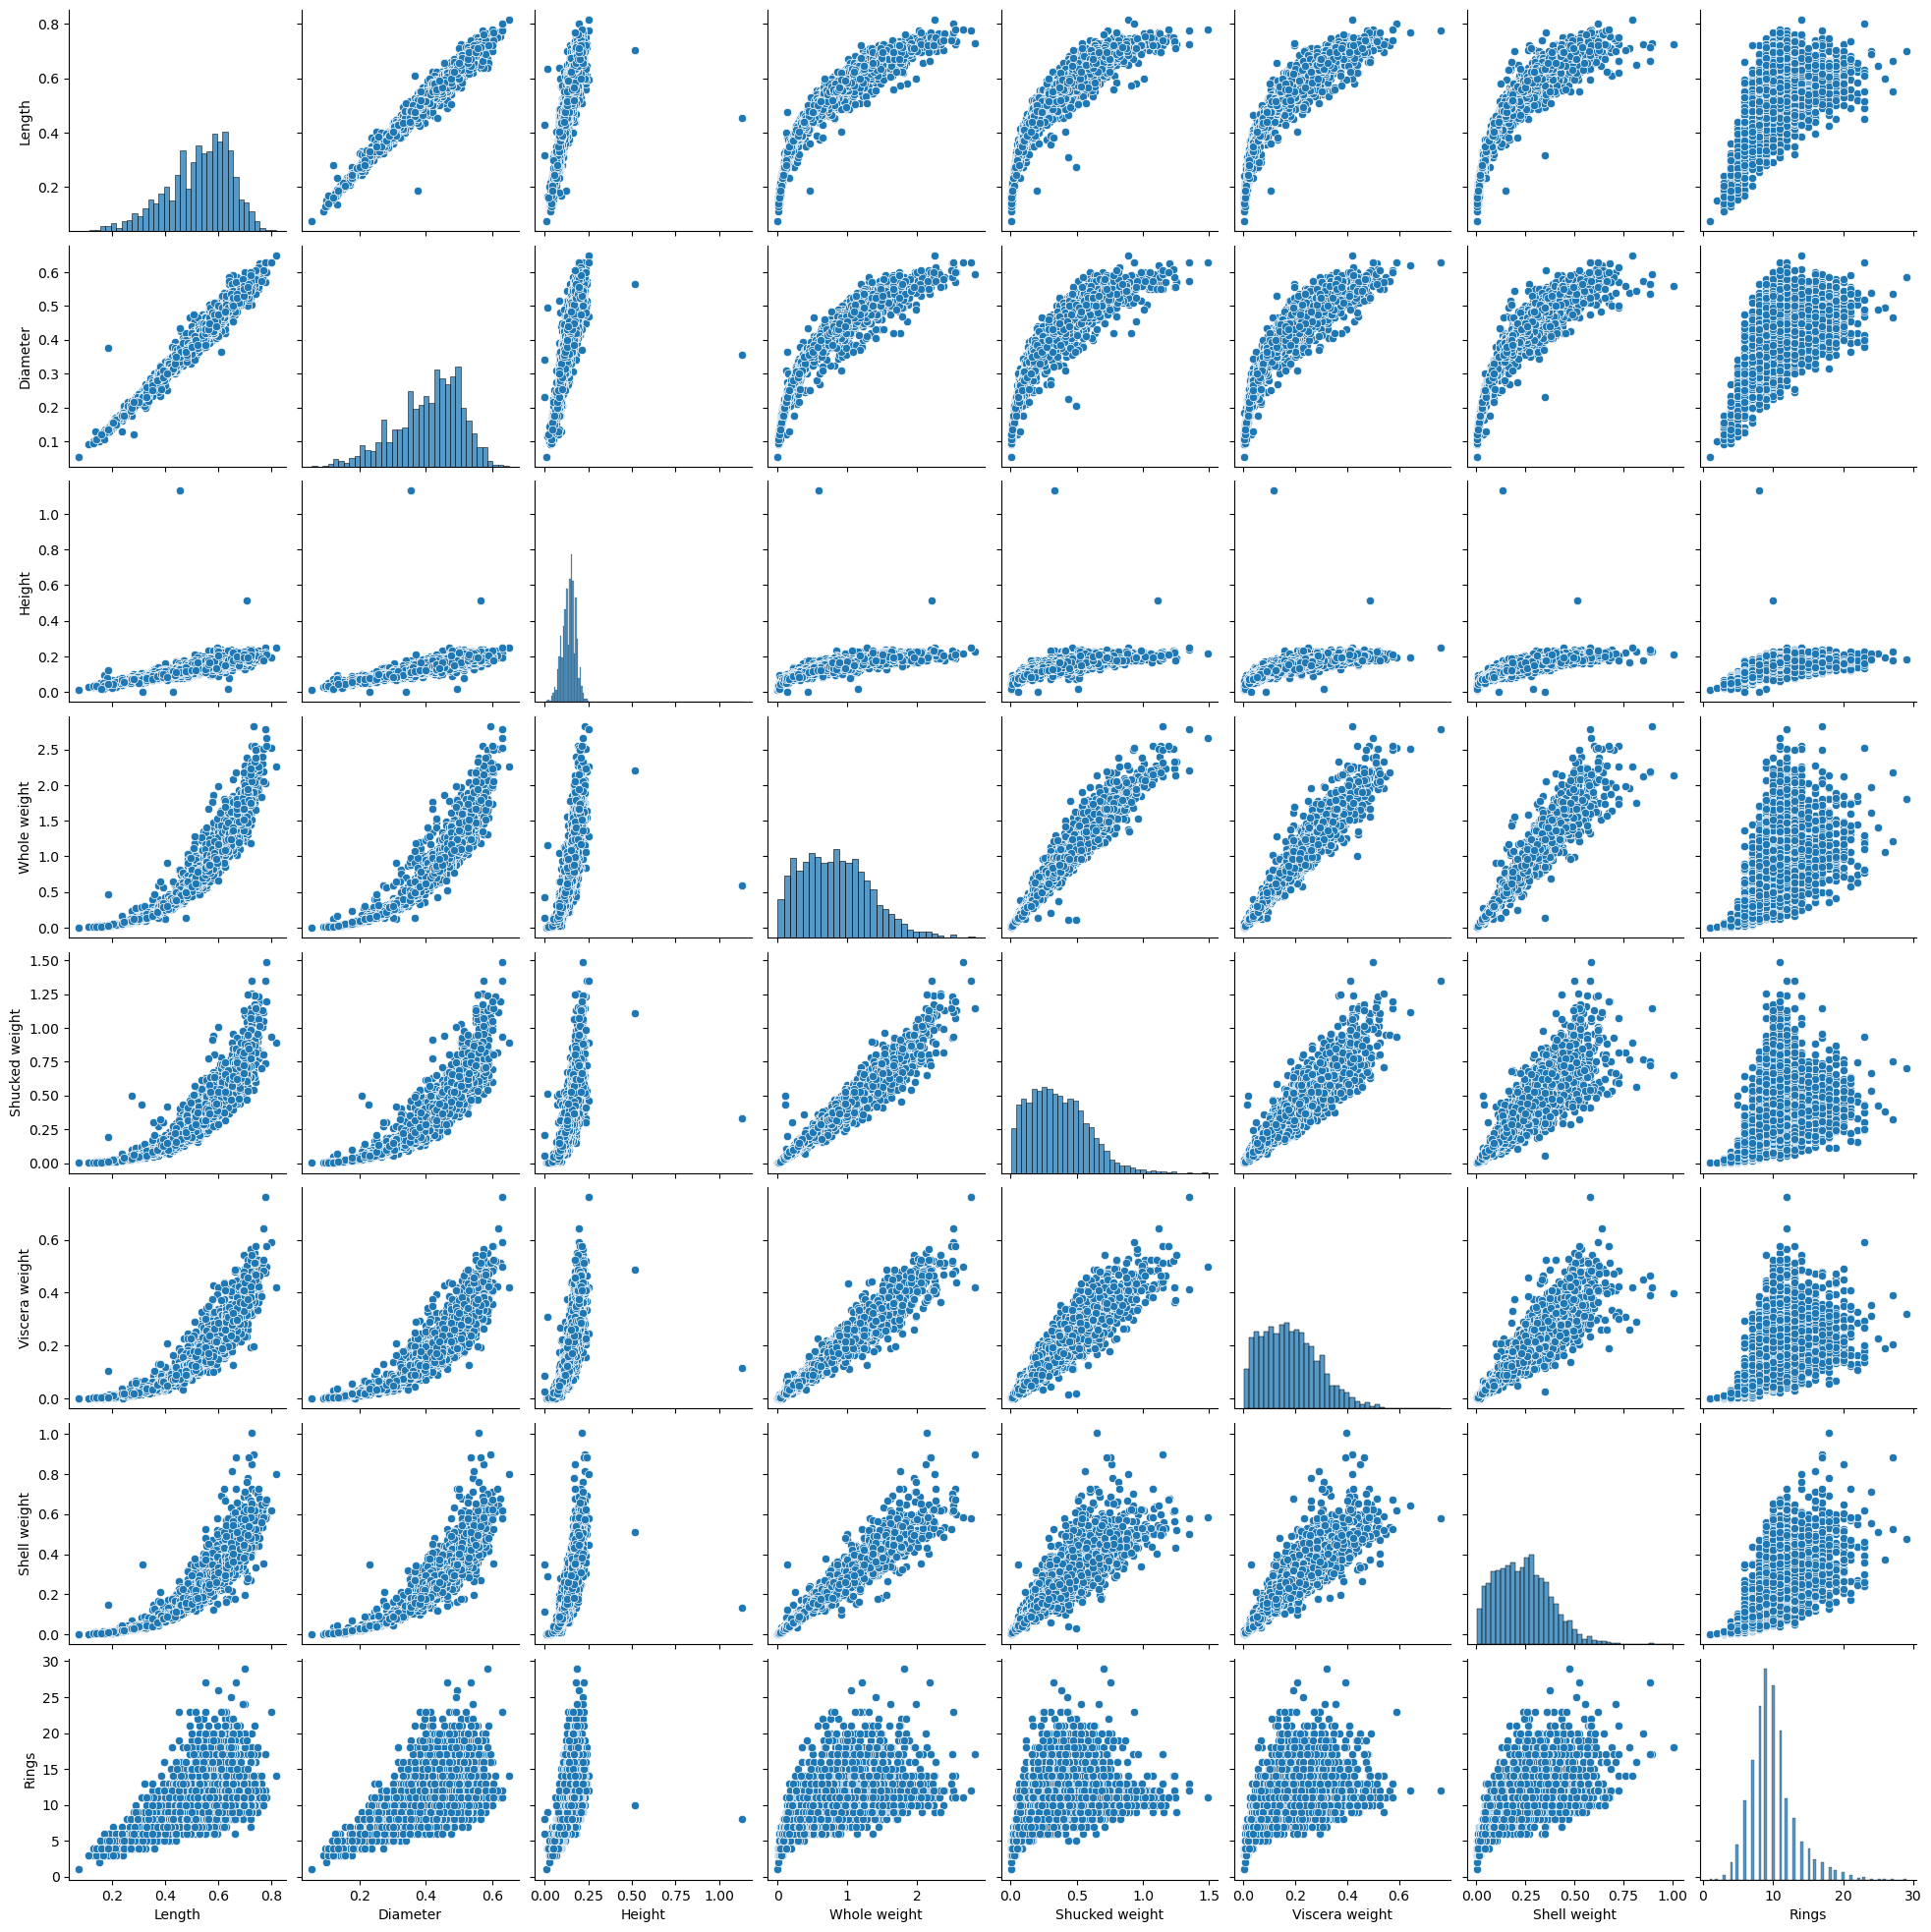

In [122]:
# Pairs plot
sns.pairplot(df)
plt.show()

In [123]:
mapping = {'I': 2, 'F': 1, 'M': 0}
df['Sex'] = df['Sex'].replace(mapping)
df.head(12)

,Sex,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings
0,0,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,0,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,1,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,0,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,2,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7
5,2,0.425,0.300,0.095,0.3515,0.1410,0.0775,0.120,8
6,1,0.530,0.415,0.150,0.7775,0.2370,0.1415,0.330,20
7,1,0.545,0.425,0.125,0.7680,0.2940,0.1495,0.260,16
8,0,0.475,0.370,0.125,0.5095,0.2165,0.1125,0.165,9
9,1,0.550,0.440,0.150,0.8945,0.3145,0.1510,0.320,19


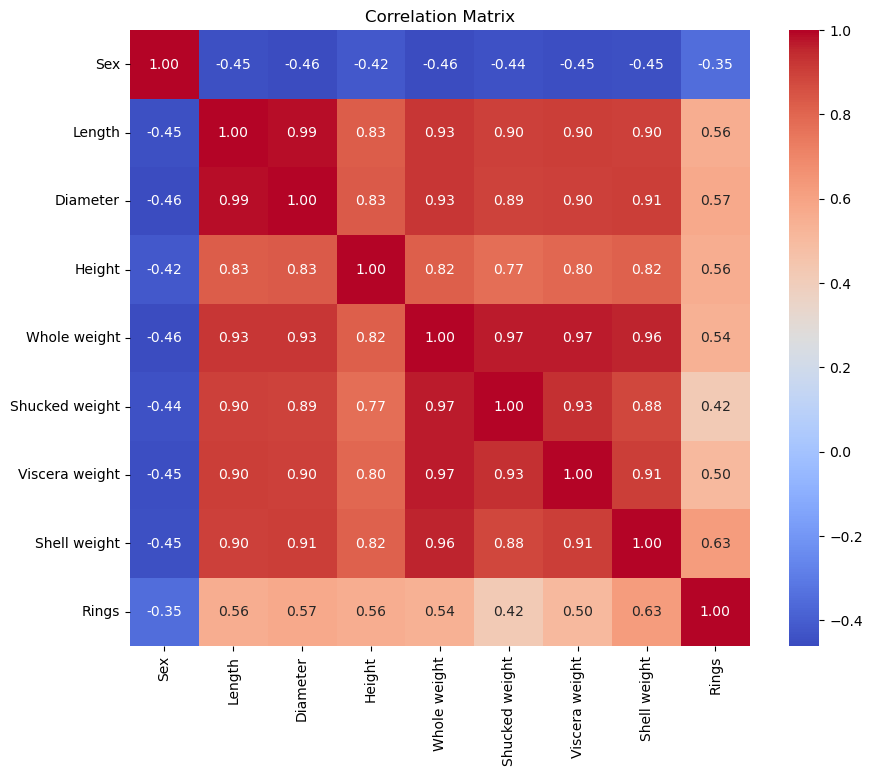

In [124]:
# Correlation matrix
correlation_matrix = df.corr() # Compute correlations
plt.figure(figsize=(10, 8)) # Adjust figure size
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

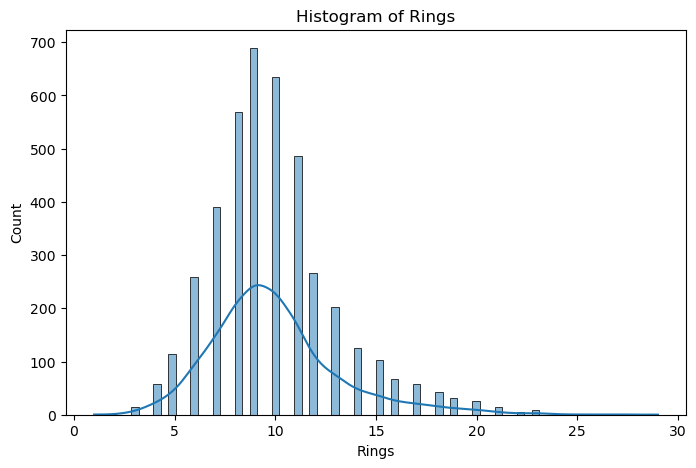

In [125]:
# Histogram of Rings
plt.figure(figsize = (8,5))
sns.histplot(df['Rings'], kde = True)
plt.title("Histogram of Rings")
plt.show()

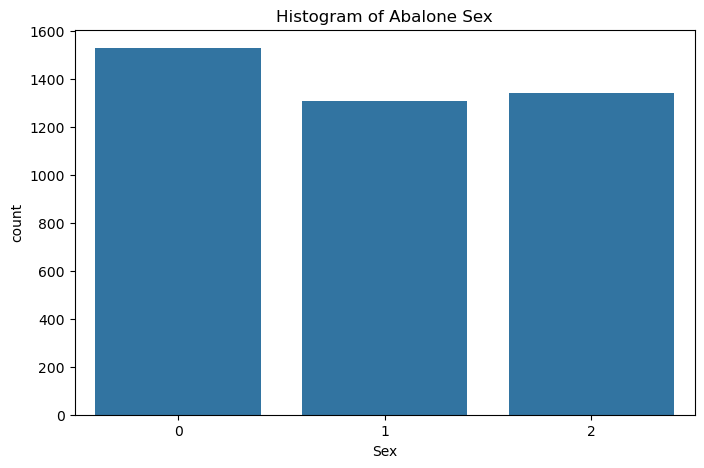

In [126]:
# Histogram of Sex variable
plt.figure(figsize=(8, 5))
sns.countplot(x='Sex', data = df)
plt.title('Histogram of Abalone Sex')
plt.show()

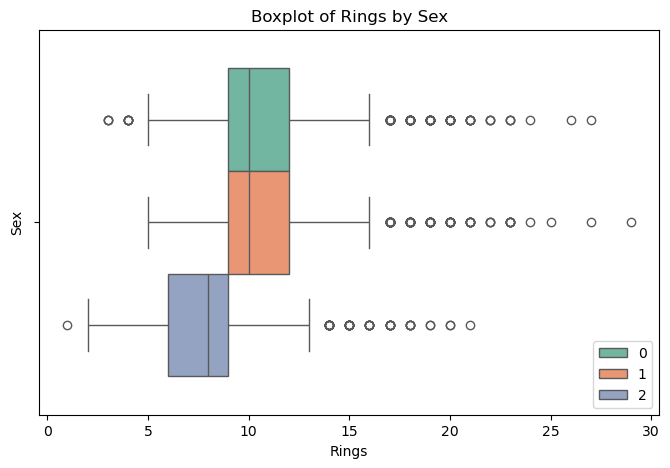

In [127]:
# Boxplots of Rings by Sex
plt.figure(figsize = (8,5))
sns.boxplot(x = 'Rings', data = df, hue = 'Sex', palette = 'Set2')
plt.legend(loc = 'lower right')
plt.title('Boxplot of Rings by Sex')
plt.xlabel("Rings")
plt.ylabel("Sex")
plt.show()

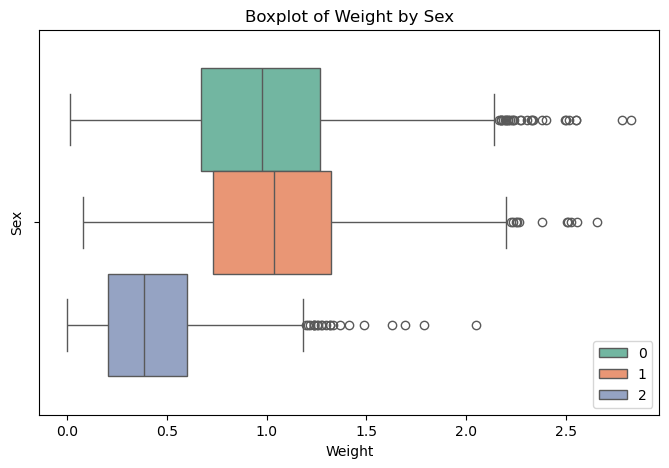

In [128]:
# Boxplots of Weight versus Sex
plt.figure(figsize = (8,5))
sns.boxplot(x = 'Whole weight', data = df, hue = 'Sex', palette = 'Set2')
plt.legend(loc = 'lower right')
plt.title('Boxplot of Weight by Sex')
plt.xlabel("Weight")
plt.ylabel("Sex")
plt.show()

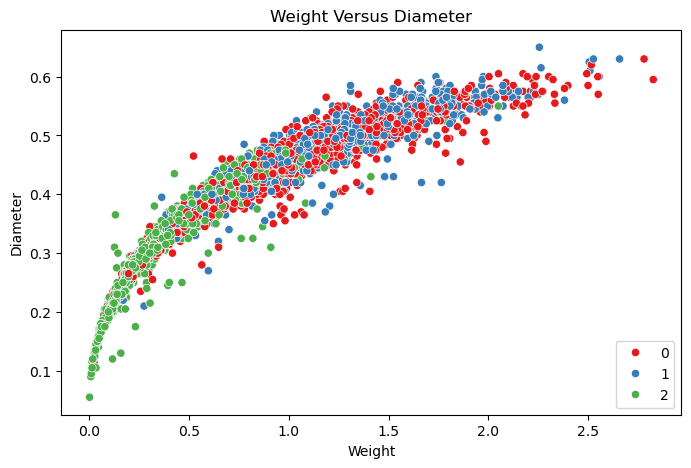

In [129]:
# Scatterplot of Height versus Weight
plt.figure(figsize = (8, 5))
sns.scatterplot(x = 'Whole weight', y = 'Diameter', hue = 'Sex', data = df, palette = 'Set1')
plt.legend(loc = 'lower right')
plt.title("Weight Versus Diameter")
plt.xlabel("Weight")
plt.ylabel("Diameter")
plt.show()

In [130]:
# Function to Plot Numerical Distribution 
def plot_numerical_distribution_with_hue(data, num_cols, hue_col='Sex', figsize=(25, 25), dpi=100):
    # Create subplots
    rows = (len(num_cols) + 1) // 2 
    fig, ax = plt.subplots(rows, 2, figsize=figsize, dpi=dpi)
    ax = ax.flatten() 
    
    # Define the palette
    palette = ['#328ca9', '#0e6ea9', '#2c4ea3', '#193882', '#102446']
    
    # Loop through each column and plot the distribution with hue
    for i, column in enumerate(num_cols):  
        sns.histplot(data=data, x=column, hue=hue_col, ax=ax[i], kde=True, palette=palette)
        ax[i].set_title(f'{column} Distribution', size=14)
        ax[i].set_xlabel(None)
        ax[i].set_ylabel(None)
        
        # Calculate skewness
        #skewness = skew(data[column].dropna())
        #skew_label = f'Skewness: {skewness:.2f}'
        
        # Add skewness annotation
        #ax[i].annotate(skew_label, xy=(0.05, 0.9), xycoords='axes fraction', fontsize=12, color='red')
    
    # Remove any extra subplots
    for j in range(len(num_cols), len(ax)):
        fig.delaxes(ax[j])
    
    # Set Tight Layout
    plt.tight_layout()
    
    # Show the plot
    plt.show()

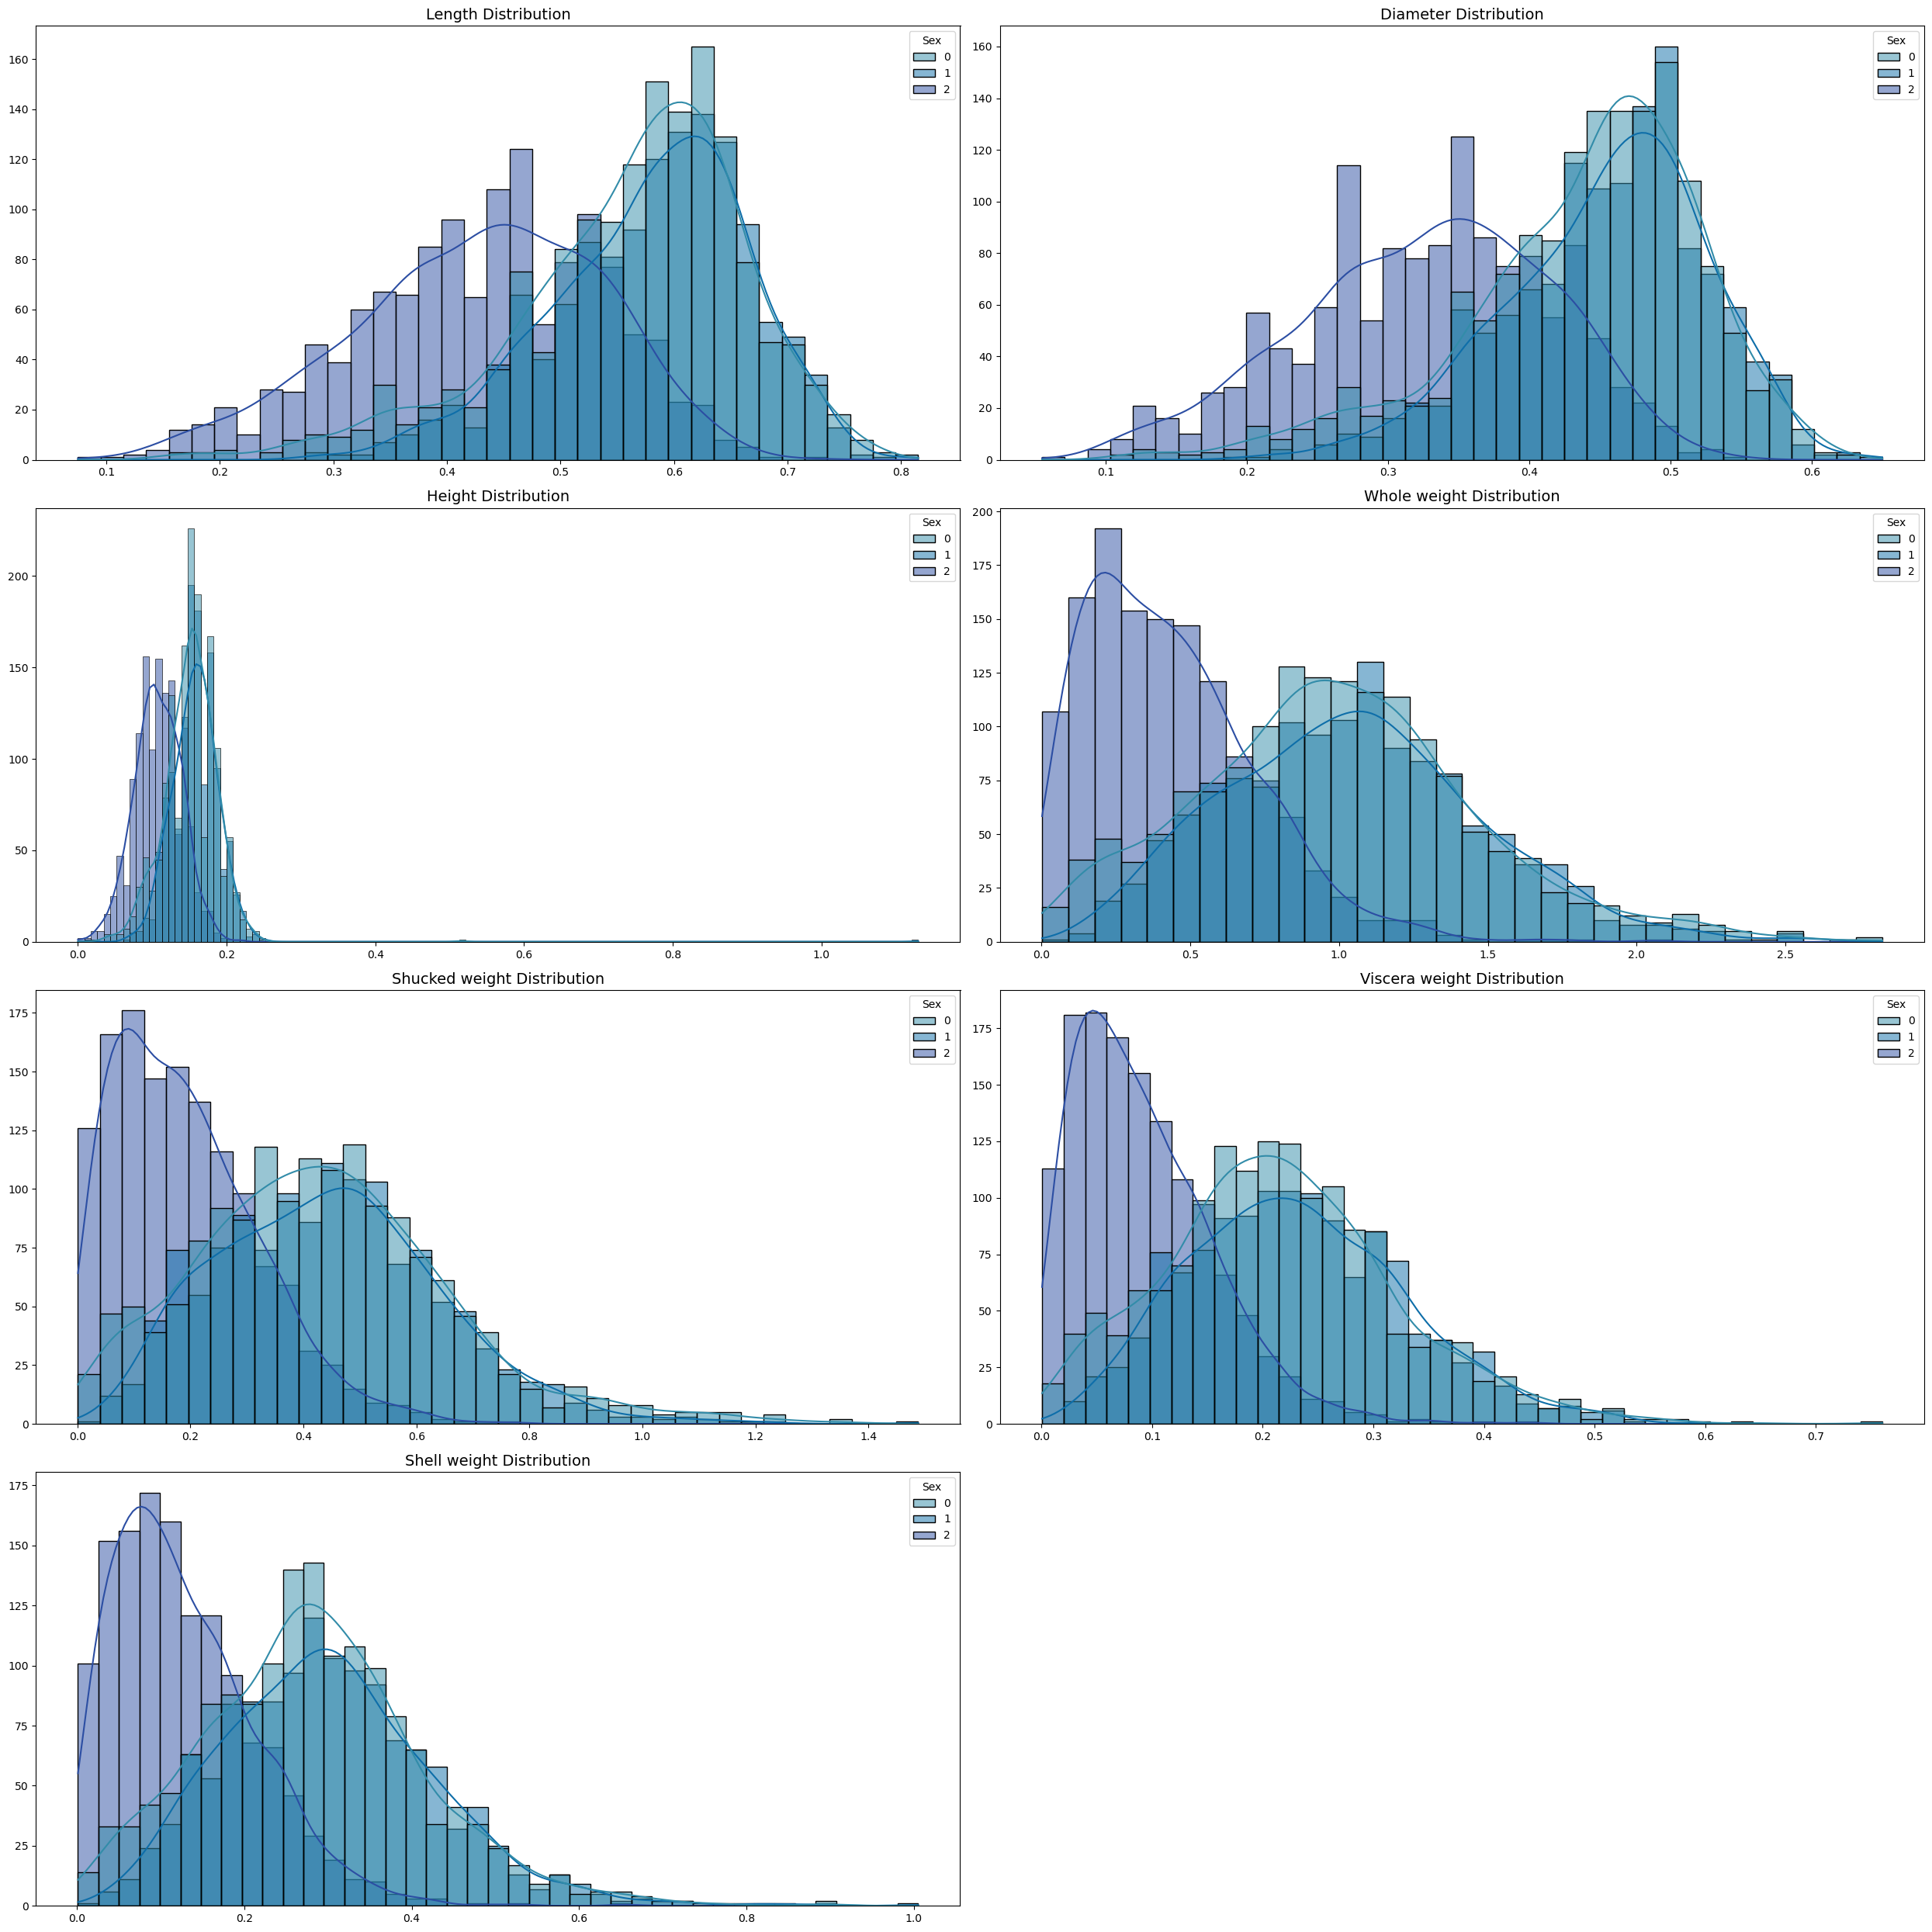

In [131]:
# Plots distributions of variables
NUM_COLS_F = [col for col in df.columns if df[col].dtype == 'float']
# Numerical Distribution of Age Vs Fare
plot_numerical_distribution_with_hue(df,NUM_COLS_F,'Sex')

## Split data in case it's needed

In [132]:
# Define X and y portions of the dataset
X = df.drop(columns = ['Rings'])
y = df['Rings']

# Split the dataset 80/20
X_train, X_test, y_train, y_test = tts(X,
                                       y,
                                       train_size = 0.8,
                                       test_size = 0.2,
                                       shuffle = True,
                                       random_state = 42)

In [157]:
feature_cols = df.columns 
model = LinearRegression()
model.fit(X, y)

# Print the intercept
print(f'Intercept: {model.intercept_}')

# Print the variables (feature names) and their coefficients
print('Coefficients:')
for feature, coef in zip(feature_cols, model.coef_):
    print(f'  {feature}: {coef}')

Intercept: 3.7592643665614167
Coefficients:
  Sex: 0.0
  Length: -0.38848319668790304
  Diameter: -0.8263990750361333
  Height: 11.964031783891384
  Whole weight: 11.204491955183812
  Shucked weight: 9.070208637871346
  Viscera weight: -20.106143639514197
  Shell weight: -10.155101056999781
  Rings: 8.70110595925302


In [155]:
import statsmodels.api as sm
# X, y = ...

# Add a constant (intercept) to the predictors
X = sm.add_constant(X) 

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Rings   R-squared:                       0.535
Model:                            OLS   Adj. R-squared:                  0.534
Method:                 Least Squares   F-statistic:                     600.3
Date:                Sat, 28 Feb 2026   Prob (F-statistic):               0.00
Time:                        19:41:46   Log-Likelihood:                -9215.6
No. Observations:                4177   AIC:                         1.845e+04
Df Residuals:                    4168   BIC:                         1.851e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              3.7593      0.283     13.

In [141]:
lr = LinearRegression().fit(X_train, y_train)

print(f"Linear Regression-Training set score: {lr.score(X_train, y_train):.2f}")
print(f"Linear Regression-Test set score: {lr.score(X_test, y_test):.2f}")

Linear Regression-Training set score: 0.53
Linear Regression-Test set score: 0.54


In [143]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=0.7).fit(X_train, y_train)
print(f"Ridge Regression-Training set score: {ridge.score(X_train, y_train):.2f}")
print(f"Ridge Regression-Test set score: {ridge.score(X_test, y_test):.2f}")

Ridge Regression-Training set score: 0.53
Ridge Regression-Test set score: 0.54


In [144]:
# Lasso with alpha = 1.0
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=1.0).fit(X_train, y_train)
print(f"Lasso Regression-Training set score: {lasso.score(X_train, y_train):.2f}")
print(f"Lasso Regression-Test set score: {lasso.score(X_test, y_test):.2f}")

Lasso Regression-Training set score: 0.00
Lasso Regression-Test set score: -0.00


In [145]:
print(f"Number of features: {sum(lasso.coef_ != 0)}")

Number of features: 0


In [146]:
# Lasso with alpha = 0.01
lasso = Lasso(alpha=0.01).fit(X_train, y_train)
print("Lasso Regression-Training set score: {:.2f}".format(lasso.score(X_train, y_train)))
print("Lasso Regression-Test set score: {:.2f}".format(lasso.score(X_test, y_test)))

Lasso Regression-Training set score: 0.51
Lasso Regression-Test set score: 0.52


In [147]:
print(f"Number of features: {sum(lasso.coef_ != 0)}")

Number of features: 6
